In [1]:
from scipy import stats
from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
import numpy as np
import statistics as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

data = pd.read_csv('nba_second_round_history_standardised.csv')

# Creative Extension

We've discovered that Deffensive Rating (DRtg) is the most important indicator for championship winnging teams in the second round data, and statistical test (Welch's T-test) revealed there exists significant difference in DRtg between champion and non-champion teams. As a creative extention, we'd like to check if teams with lower DRtg (below PR 50) have higher proportion of championship-winning teams.

In [2]:
median = data['Defensive Rating'].median()
better_D = data[data['Defensive Rating'] < median]
worse_D = data[data['Defensive Rating'] >= median]

                       Group  Total Teams  Champions  Championship Proportion
0      Dominant (4-0 or 4-1)           86         27                 0.313953
1  Non-dominant (4-2 or 4-3)           86         16                 0.186047


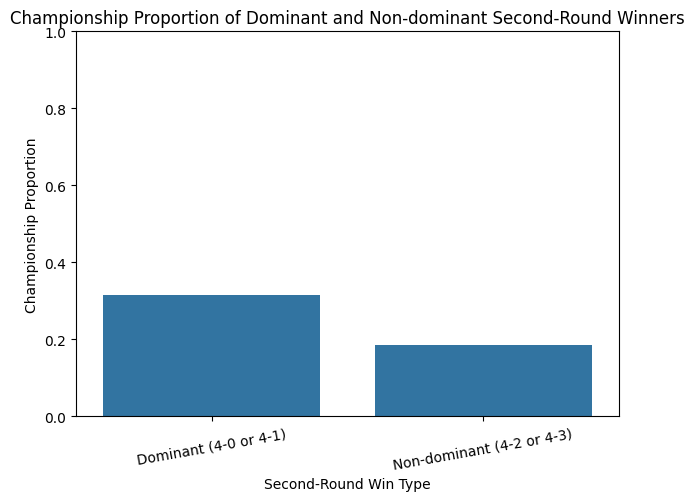

In [5]:
# Descriptive plot for RQ1:
# Championship proportion of dominant vs non-dominant second-round winners

dominance_summary = pd.DataFrame({
    "Group": ["Dominant (4-0 or 4-1)", "Non-dominant (4-2 or 4-3)"],
    "Total Teams": [len(better_D), len(worse_D)],
    "Champions": [
        better_D["Champion"].sum(),
        worse_D["Champion"].sum()
    ],
})

dominance_summary["Championship Proportion"] = (
    dominance_summary["Champions"] / dominance_summary["Total Teams"]
)

print(dominance_summary)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=dominance_summary,
    x="Group",
    y="Championship Proportion"
)

plt.title("Championship Proportion of Dominant and Non-dominant Second-Round Winners")
plt.xlabel("Second-Round Win Type")
plt.ylabel("Championship Proportion")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.show()

In [6]:
# check if two sample proportion z-test is appropriate
n1p1 = len(better_D[better_D['Champion'] == True])
n1q1 = len(better_D) - n1p1
n2p2 = len(worse_D[worse_D['Champion'] == True])
n2q2 = len(worse_D) - n2p2
if n1p1 >= 15 and n1q1 >= 15 and n2p2 >= 15 and n2q2 >= 15:
    print("Two-sample proportion z-test is appropriate.")
if n1p1 < 15:
    print(f"Two-sample proportion z-test is not appropriate. Number of dominant champions is less than 15 ({n1p1}).")
if n1q1 < 15:
    print(f"Two-sample proportion z-test is not appropriate. Number of dominant non-champions is less than 15 ({n1q1}).")
if n2p2 < 15:
    print(f"Two-sample proportion z-test is not appropriate. Number of non-dominant champions is less than 15 ({n2p2}).")
if n2q2 < 15:
    print(f"Two-sample proportion z-test is not appropriate. Number of non-dominant non-champions is less than 15 ({n2q2}).")

Two-sample proportion z-test is appropriate.


H0: p1 = p2 ;
H1: p1 > p2

In [ ]:
test_stat, p_value = proportions_ztest([n1p1, n2p2], [len(better_D), len(worse_D)], alternative='larger')
print(f"Z-test statistic: {test_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject the null hypothesis: The championship rates in teams with higher DRtg are large.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in championship rates between teams with higher and lower DRtg.")

CI_low, _ = confint_proportions_2indep(
    count1=n1p1,
    nobs1=len(better_D),
    count2=n2p2,
    nobs2=len(worse_D),
    method='wald',
    alpha=0.10
)    
print(f'Confindence Interval: ({CI_low:.4f}, 1.0000)')

SE = math.sqrt(n1p1*n1q1/len(better_D)**3 + n2p2*n2q2/len(worse_D)**3)
CI_low = n1p1/len(better_D) - n2p2/len(worse_D) - stats.norm.ppf(0.95) * SE
# CI_high = n1p1/len(better_D) - n2p2/len(worse_D) + stats.norm.ppf(0.95) * SE
print(f'Confident Interval (hand calculated): ({CI_low:.4f}, 1.0000)')
sampling_error = stats.norm.ppf(0.95) * SE
print(f'Sampling error is {sampling_error * 100 :.4f}%')

Z-test statistic: 1.9370
P-value: 0.0264
Reject the null hypothesis: The championship rates in teams with higher DRtg are large.
Confindence Interval: (0.0205, 1.0000)
Confident Interval (hand calculated): (0.0205, 1.0000)
Sampling error is 10.7425%


# Conclusion

Interestingly, this result echoes one of the arguments frequently raised in discussions surrounding Nico Harrison's controversial decision to trade Luka Dončić: namely, that championship contenders require a strong defensive foundation. Whilst the present analysis cannot assess the merits of that specific transaction, it does suggest that teams exhibiting stronger defensive performance in the second round are more likely to go on to win the championship.